# Activity 2: Statistical Outlier Detection

**Week 6 Day 2 · Machine Learning for Data Cleaning**

**Estimated time:** 80 minutes (Parts 1 to 7), plus 30 minutes for Your Turn
**Difficulty:** Intermediate
**Format:** Individual, with a prediction checkpoint before Part 7 best done in pairs
**Prerequisites:** Activity 1, plus quartiles and standard deviation from any intro statistics course

## An outlier is not a fact about a row

In Activity 1 you dealt with values that were absent. Now you deal with values that are present, but wrong. Or unusual. Or perfectly correct and simply surprising.

That ambiguity is the whole difficulty. There is no test that tells you a value is an outlier, because **"outlier" is not a property a data point has**. It is a statement about how a point relates to a reference population, and the moment you change the reference, the answer changes.

A 250 pound adult is unremarkable among adults and extraordinary among children. A fare of 400 dollars is fraud in Manhattan and a normal airport run in some cities. Nothing about the number changed. The comparison did.

So the engineering question is never "is this an outlier". It is:

> **Compared to what, and what do we do about it?**

## Why start with statistics rather than ML

You could reach straight for an ML detector. You should not, for three reasons:

1. **The statistical methods are often sufficient.** A great many production quality checks are an IQR rule that took four lines to write.
2. **They are explainable.** When an analyst asks why a record was quarantined, "it was more than three standard deviations below the mean" is an answer. "The ensemble scored it -0.31" is not.
3. **They give you a baseline.** The same discipline as Activity 1 applies. If the ML detector cannot beat a Z-score, it has not earned its dependency.

In this activity you build the statistical toolkit and, more importantly, find precisely where it breaks. Activity 3 picks up from that breaking point.

## Learning objectives

By the end of this activity you will be able to:

1. Apply Tukey's IQR method, Z-scores, and Modified Z-scores, and state what each assumes.
2. Explain why the mean and standard deviation are the wrong tools for finding extreme values.
3. Demonstrate that univariate methods are blind to anomalies that only exist across columns.
4. Distinguish point, contextual, and collective anomalies.
5. Show, with labelled real world events, that statistical methods on a time series miss anomalies entirely.

---
## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_rows", 12)

This activity uses `matplotlib` for the plots and `scipy` for the chi-squared threshold in Part 5, on top of the base project's `pandas` and `numpy`. All four are declared in the repo-root `pyproject.toml`, so `uv sync` from the repository root installs them. Run that once if you have not since they were added.

The next cell builds `DATA_DIR` by walking up from wherever the notebook is running until it finds `pyproject.toml`, the marker for the repository root. That means the path resolves correctly whether you run this notebook from the course folder or from your own copy under `student-work/week6/day2/`, without you hardcoding it.

In [2]:
from pathlib import Path


def find_repo_root(start=None):
    """Walk upward until we find the repo root (the folder holding pyproject.toml)."""
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repo root from " + str(start))


DATA_DIR = find_repo_root() / "Week 6" / "Labs" / "Day 2" / "data"

---
# Part 1: Look at the data first

Load a dataset of 10,000 human height and weight measurements.

In [3]:
people = pd.read_csv(DATA_DIR / "weight-height.csv")
people.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
people.describe().round(2)

,Height,Weight
count,10000.00,10000.00
mean,66.37,161.44
std,3.85,32.11
min,54.26,64.70
25%,63.51,135.82
50%,66.32,161.21
75%,69.17,187.17
max,79.00,269.99


Nothing obviously broken. Heights run from 54 to 79 inches, weights from 65 to 270 pounds. All physically possible.

Before computing anything, plot it. Every statistical method you are about to use makes an assumption about the shape of this distribution, and you can check that assumption by eye in one chart.

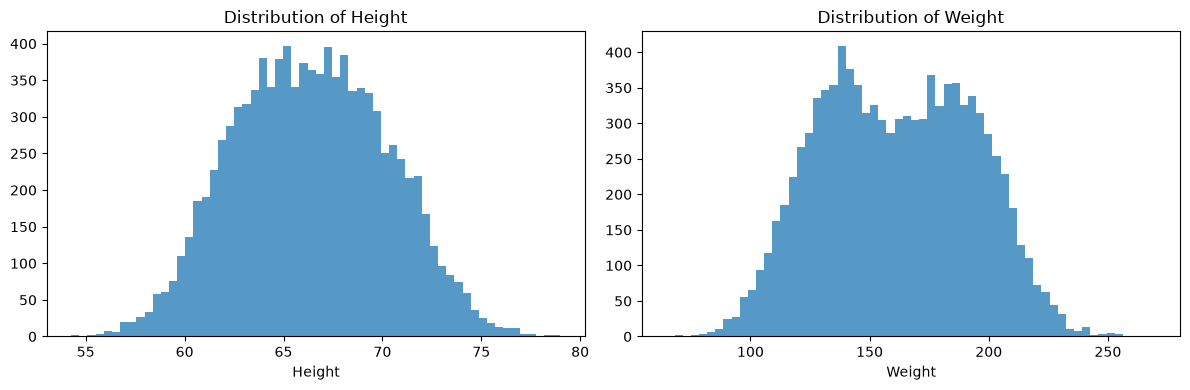

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Height", "Weight"]):
    ax.hist(people[col], bins=60, color="tab:blue", alpha=0.75)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

Look closely at those shapes. Neither is a single clean bell curve. Both are wide and flat topped, and `Height` in particular hints at **two overlapping humps**.

There is a reason for that, and the dataset tells you what it is.

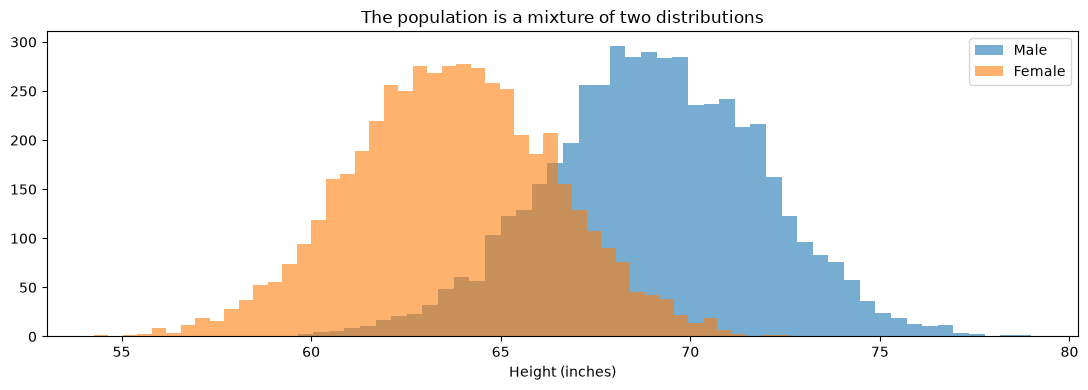

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
for gender, colour in [("Male", "tab:blue"), ("Female", "tab:orange")]:
    ax.hist(people.loc[people["Gender"] == gender, "Height"],
            bins=50, alpha=0.6, label=gender, color=colour)
ax.set_xlabel("Height (inches)")
ax.set_title("The population is a mixture of two distributions")
ax.legend()
plt.tight_layout()
plt.show()

This is a **mixture of two populations**, each roughly normal, with different means.

Remember this when the numbers start coming out strangely later. Every method in this notebook assumes it is looking at one population. It is not.

This is not a contrived teaching dataset quirk. Mixed populations are the normal case in production data. Retail transactions mix consumer and wholesale. Server latency mixes cache hits and cache misses. API traffic mixes humans and bots. If you compute one threshold across a mixture, you get a threshold that describes neither group.

---
# Part 2: Tukey's IQR method

The oldest and most robust approach. It uses quartiles rather than the mean.

- **Q1** is the value below which 25 percent of the data falls.
- **Q3** is the value below which 75 percent falls.
- **IQR** is `Q3 - Q1`, the range of the middle half of the data.

Anything further than `1.5 x IQR` beyond either quartile is flagged.

The reason this is robust is that quartiles are **positional**. Making the largest value in your dataset a million times larger does not move Q3 at all, because Q3 only cares about which value sits at that position.

**Go deeper:** the rule is John Tukey's, from *Exploratory Data Analysis* (1977), and the [NIST/SEMATECH Engineering Statistics Handbook](https://www.itl.nist.gov/div898/handbook/prc/section1/prc16.htm) is the free reference that treats it alongside the alternatives. If you have ever wondered why `1.5` and not some other number, Tukey's own answer was essentially that it worked well in practice, which is worth knowing before you defend the value in a design review.

In [53]:
def iqr_outliers(series, k=1.5):
    """Flag values beyond k * IQR from the quartiles. Returns a boolean Series."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series < lower) | (series > upper)

In [54]:
height_iqr = iqr_outliers(people["Height"])
weight_iqr = iqr_outliers(people["Weight"])

print("Height outliers by IQR:", height_iqr.sum())
print("Weight outliers by IQR:", weight_iqr.sum())

Height outliers by IQR: 8
Weight outliers by IQR: 1


Out of 10,000 rows, a very small number. This distribution is well behaved at its edges.

A box plot draws exactly this rule, which is why box plots are the fastest visual outlier check available.

/var/folders/48/j6k669vx63qd_68k2_502cl40000gn/T/ipykernel_24391/2852165374.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([people["Height"], people["Weight"]], vert=False, tick_labels=["Height", "Weight"])


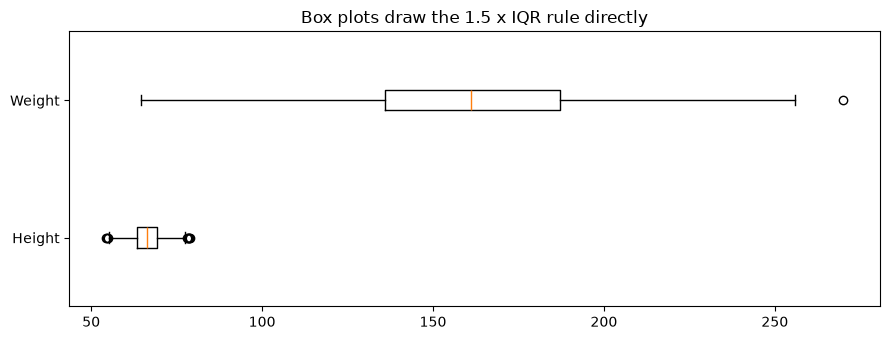

In [55]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.boxplot([people["Height"], people["Weight"]], vert=False, tick_labels=["Height", "Weight"])
ax.set_title("Box plots draw the 1.5 x IQR rule directly")
plt.tight_layout()
plt.show()

## The multiplier is a policy decision

The 1.5 is a convention, not a law. It is a dial that trades false positives against missed detections.

In [56]:
for k in [1.0, 1.5, 2.0, 3.0]:
    n = iqr_outliers(people["Height"], k=k).sum()
    print(f"k = {k:<4} flags {n:>4} rows ({n / len(people):.2%})")

k = 1.0  flags  173 rows (1.73%)
k = 1.5  flags    8 rows (0.08%)
k = 2.0  flags    0 rows (0.00%)
k = 3.0  flags    0 rows (0.00%)


`k` is not just a number in a printout. It is a boundary you can see move. Plot Height's distribution once, and draw the cutoff for each `k` from the loop above.

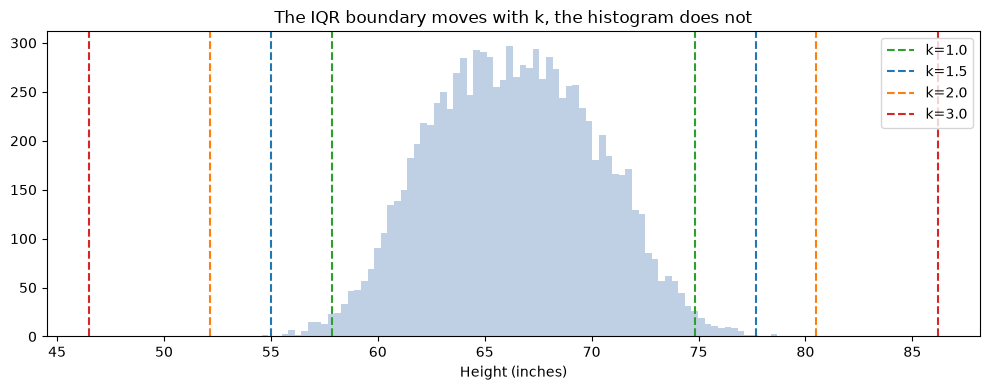

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(people["Height"], bins=80, color="lightsteelblue", alpha=0.8)

q1, q3 = people["Height"].quantile([0.25, 0.75])
iqr = q3 - q1
for k, color in {1.0: "tab:green", 1.5: "tab:blue", 2.0: "tab:orange", 3.0: "tab:red"}.items():
    lower, upper = q1 - k * iqr, q3 + k * iqr
    ax.axvline(lower, color=color, ls="--", lw=1.5, label=f"k={k}")
    ax.axvline(upper, color=color, ls="--", lw=1.5)

ax.set_xlabel("Height (inches)")
ax.set_title("The IQR boundary moves with k, the histogram does not")
ax.legend()
plt.tight_layout()
plt.show()

Notice how much territory opens up between `k=1.0` and `k=3.0`, and match it against the counts in the printout above.

At `k=1.0` the boundary sits well inside the main body of the distribution, which is why it flagged 173 rows. At `k=1.5` it flags 8. At `k=2.0` and beyond it flags **nothing at all**, because the boundary has moved past the largest value in the dataset.

That last point is worth pausing on. A quality check reporting zero outliers can mean the data is clean, or it can mean the threshold is looser than the data's own range and the check cannot fire. Those two situations produce an identical output, and only one of them is good news.

There is no correct line in this picture. There is only the line that matches how much review capacity you have and how expensive a miss is.

Choosing `k` is a business conversation, not a statistical one. The right question is what each kind of mistake costs.

If a flagged record means a human reviews it, a high false positive rate is expensive in salary. If a missed record means a fraudulent claim gets paid, a missed detection is expensive in cash. Set `k` accordingly and document why.

### Try it yourself

Before moving on, run one experiment of your own in the cell below.

`Weight` has a wider spread than `Height`. Does that make it more or less sensitive to `k`?

1. Run the same `k` sweep on `people["Weight"]` instead of `Height`.
2. Find the smallest `k` at which `Weight` flags zero rows.

**What to look for:** `Height` went silent at `k=2.0`. Does `Weight` go silent at the same point, earlier, or later?

**Why it matters:** if one column stops producing alerts at a much lower `k` than another, a single shared threshold across your table is quietly doing very different jobs in different columns.

In [12]:
# Your turn: sweep k on Weight and find where it goes silent.
# Hint: copy the loop from the cell above and change the column.



---
# Part 3: Z-scores, and why they undermine themselves

The Z-score expresses each value as a number of standard deviations from the mean.

A common rule flags anything beyond 3.

In [60]:
def z_score_outliers(series, threshold=3.0):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

In [61]:
print("Height outliers by Z-score:", z_score_outliers(people["Height"]).sum())
print("Weight outliers by Z-score:", z_score_outliers(people["Weight"]).sum())

Height outliers by Z-score: 7
Weight outliers by Z-score: 2


Counts alone hide how these points sit relative to the threshold. Plot the Z-scores themselves, with the cutoff drawn in, and the flagged points marked.

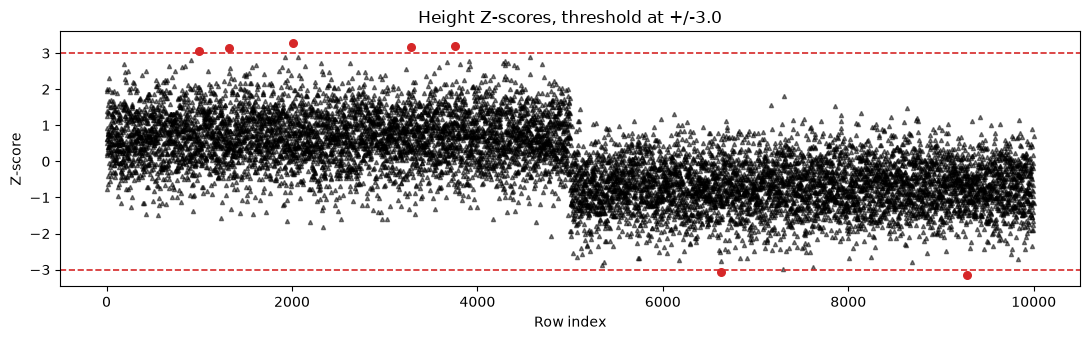

In [62]:
def plot_scores(series, threshold, label, ax):
    """Scatter a score series with its +/- threshold lines, and mark the flagged points."""
    ax.plot(series.index, series.values, "^", color="black", markersize=3, alpha=0.5)
    ax.axhline(threshold, color="tab:red", ls="--", lw=1.2)
    ax.axhline(-threshold, color="tab:red", ls="--", lw=1.2)
    flagged = series[series.abs() > threshold]
    ax.scatter(flagged.index, flagged.values, color="tab:red", s=30, zorder=3)
    ax.set_ylabel(label)


height_z = (people["Height"] - people["Height"].mean()) / people["Height"].std()

fig, ax = plt.subplots(figsize=(11, 3.5))
plot_scores(height_z, threshold=3.0, label="Z-score", ax=ax)
ax.set_xlabel("Row index")
ax.set_title("Height Z-scores, threshold at +/-3.0")
plt.tight_layout()
plt.show()

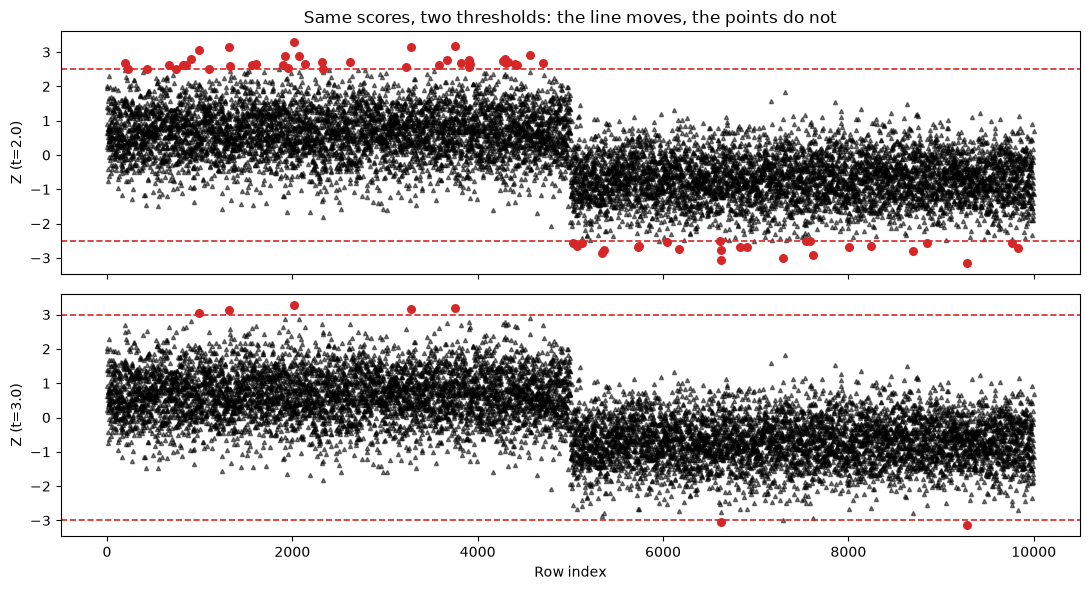

In [67]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
plot_scores(height_z, threshold=2.5, label="Z (t=2.0)", ax=axes[0])
plot_scores(height_z, threshold=3.0, label="Z (t=3.0)", ax=axes[1])
axes[0].set_title("Same scores, two thresholds: the line moves, the points do not")
axes[-1].set_xlabel("Row index")
plt.tight_layout()
plt.show()

Same Z-scores in both panels. Only the dashed line moved. At `t=2.0` more points fall outside it and get flagged; at `t=3.0` the line sits further out and only the most extreme survive. This is the same policy dial as `k` in the IQR method, just measured in standard deviations instead of quartile widths.

Broadly similar to IQR here. But the Z-score has a structural weakness that this clean dataset hides, and it is worth seeing plainly.

**The mean and standard deviation are themselves distorted by the outliers you are hunting.**

Take a small clean sample and inject one extreme value.

In [17]:
clean = pd.Series([10, 11, 12, 11, 10, 12, 11, 10, 11, 12], dtype=float)
contaminated = pd.concat([clean, pd.Series([500.0])], ignore_index=True)

print("Clean        mean = %.2f, std = %.2f" % (clean.mean(), clean.std()))
print("Contaminated mean = %.2f, std = %.2f" % (contaminated.mean(), contaminated.std()))

Clean        mean = 11.00, std = 0.82
Contaminated mean = 55.45, std = 147.44


One bad value dragged the mean from 11 to 55 and inflated the standard deviation from about 0.8 to 147.

Now ask the Z-score to find it.

In [18]:
z = (contaminated - contaminated.mean()) / contaminated.std()
print("Z-score of the value 500:", round(z.iloc[-1], 3))
print("Flagged at threshold 3?", abs(z.iloc[-1]) > 3)

Z-score of the value 500: 3.015
Flagged at threshold 3? True


**It flagged it. Barely.**

A Z-score of about 3.015 against a threshold of 3.0. The value is 500 in a sample whose other members are all between 10 and 12, and the most extreme thing imaginable clears the bar by 0.015.

That margin should bother you. The outlier inflated the standard deviation so much that even a value forty times larger than everything around it only just qualifies as unusual. It very nearly hid inside the ruler you were using to measure it.

There is a reason the number landed exactly there, and it is not a coincidence.

**With `n` data points, the largest Z-score that can possibly occur is `(n-1)/sqrt(n)`**, no matter how extreme the value is. The mean and the standard deviation are both computed from the same points you are testing, so one value cannot run away from a ruler it is helping to build.

This bound is not folklore. It was published by [Shiffler (1988), *Maximum Z Scores and Outliers*](https://doi.org/10.1080/00031305.1988.10475530), and it is the reason serious outlier tests such as [Grubbs' test](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h1.htm) use critical values that depend on `n` instead of a fixed cutoff like 3.

Check the ceiling for a few sample sizes.

In [19]:
for n in [5, 10, 11, 30, 100]:
    print(f"n = {n:>3}  maximum achievable Z-score = {(n - 1) / np.sqrt(n):.3f}")

n =   5  maximum achievable Z-score = 1.789
n =  10  maximum achievable Z-score = 2.846
n =  11  maximum achievable Z-score = 3.015
n =  30  maximum achievable Z-score = 5.295
n = 100  maximum achievable Z-score = 9.900


Find `n = 11` in that list. The ceiling is **3.015**, which is exactly the Z-score you just computed for the value 500.

That is the real result. The 500 was not measured and found to be extreme. It was **pinned against the mathematical maximum** and happened to land a hair above the threshold. Anything you put in that slot, 500 or 5,000 or 5,000,000, produces the same 3.015.

Two consequences follow, and both cause real incidents:

- With 10 observations the ceiling is about 2.85, so **a threshold of 3.0 can never flag anything at all**. The check runs, reports clean, and is incapable of doing otherwise.
- If you apply a fixed Z-score threshold to small groups, for example per customer, per device, or per store, some of those groups are mathematically incapable of ever producing an alert. Your monitoring has silent dead zones and nothing in the output says so.

## Now the failure the Z-score is actually famous for

One outlier scraped past. The interesting question is what happens when there is more than one.

Real contamination rarely arrives alone. A sensor that fails usually fails for several readings. A bad ETL run corrupts a batch, not a row. Add copies of the same extreme value and watch the Z-score of each one.

In [20]:
for n_bad in [1, 2, 3, 4]:
    sample = pd.concat([clean, pd.Series([500.0] * n_bad)], ignore_index=True)
    z_bad = ((sample - sample.mean()) / sample.std()).iloc[-1]
    print(f"{n_bad} copies of 500  ->  each scores Z = {z_bad:.3f}   "
          f"flagged at 3.0? {abs(z_bad) > 3}")

1 copies of 500  ->  each scores Z = 3.015   flagged at 3.0? True
2 copies of 500  ->  each scores Z = 2.141   flagged at 3.0? False
3 copies of 500  ->  each scores Z = 1.754   flagged at 3.0? False
4 copies of 500  ->  each scores Z = 1.524   flagged at 3.0? False


**The scores go down as the problem gets worse.**

One copy scores 3.015 and is flagged. Three copies score 1.754 each and none of them is flagged. The data got four times more corrupted and the detector got quieter.

This is **masking**. Each extreme value contributes to the standard deviation, so a group of them collectively inflates the ruler until no member of the group looks far from the mean. They hide each other.

Sit with how bad that is as an operational property. The Z-score is least likely to fire exactly when the most is wrong. A single stray reading might trip it; a systematic failure that corrupts a whole batch will not. That is the opposite of what you want from a monitor.

Now compare how the robust method handles the same four samples.

In [21]:
for n_bad in [1, 2, 3, 4]:
    sample = pd.concat([clean, pd.Series([500.0] * n_bad)], ignore_index=True)
    print(f"{n_bad} copies of 500  ->  IQR flags {int(iqr_outliers(sample).sum())} of them")

1 copies of 500  ->  IQR flags 1 of them
2 copies of 500  ->  IQR flags 2 of them
3 copies of 500  ->  IQR flags 3 of them
4 copies of 500  ->  IQR flags 0 of them


IQR catches all of them up to three copies, where the Z-score had already gone silent. Quartiles are positional, so making a value larger does not move Q3.

But look at the fourth row. **With four copies, IQR flags nothing either.**

That is not a bug, it is IQR's own limit becoming visible. Four bad values out of fourteen is nearly 29 percent contamination. Once the corrupt values make up that much of the sample they stop being the tail and start being part of the middle half, so they drag Q3 out to meet themselves.

Every robust method has a **breakdown point**: the proportion of contamination it can absorb before it stops working. No method is robust to unlimited contamination, and a method that reports zero outliers is not automatically telling you the data is clean. It may be telling you the data is so corrupt that it no longer has a stable notion of normal.

The [breakdown point](https://en.wikipedia.org/wiki/Robust_statistics#Breakdown_point) is a precise, published quantity for each estimator, not a vague idea. The mean has a breakdown point of 0, meaning a single bad value can move it anywhere. The median has 50 percent, the theoretical maximum. That single fact explains every result in Parts 3 and 4, and it is the reason the Modified Z-score survived a case that silenced both of the others.

This is the single most useful reflex to take from Part 3: **when a detector suddenly goes quiet, check whether the data got cleaner or the detector got overwhelmed.** They look identical in the output.

Part 4 introduces a method that survives all four cases.

---
# Part 4: The Modified Z-score

The fix is to keep the Z-score idea, distance from centre measured in units of spread, but build both pieces from statistics that resist contamination:

- Replace the mean with the **median**, the middle value.
- Replace the standard deviation with the **MAD**, the Median Absolute Deviation: take each point's distance from the median, then take the median of those distances.

MAD is a median of medians, so it inherits the same positional stubbornness that makes IQR robust. Making one value enormous changes its own distance from the median, but it does not change which distance sits in the middle of the list.

## Where 0.6745 comes from

You will see this constant in every implementation and almost never see it explained.

MAD and the standard deviation measure spread on different scales. For normally distributed data the MAD is consistently smaller: it converges to about 0.6745 standard deviations, because 0.6745 is the point below which 75 percent of a standard normal distribution falls. Dividing by that constant, or equivalently multiplying by it in the numerator as we do below, rescales MAD so a Modified Z-score is directly comparable to an ordinary Z-score.

This is why the conventional threshold is **3.5** rather than 3.0. Without the rescaling the two scores would not be on speaking terms and the thresholds you know would not transfer.

**Go deeper:** the 3.5 cutoff comes from Iglewicz and Hoaglin's *How to Detect and Handle Outliers* (1993), summarised in the [NIST handbook's section on the modified Z-score](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm). You do not have to write the MAD by hand in practice: [`scipy.stats.median_abs_deviation`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.median_abs_deviation.html) computes it, and passing `scale="normal"` applies the same 0.6745 rescaling for you. Writing it out once, as we do here, is worth doing so the constant stops being magic.

Watch what it does on the same four contaminated samples.

In [22]:
def modified_z_outliers(series, threshold=3.5):
    median = series.median()
    mad = (series - median).abs().median()
    if mad == 0:
        return pd.Series(False, index=series.index)
    modified_z = 0.6745 * (series - median) / mad
    return modified_z.abs() > threshold

In [23]:
for n_bad in [1, 2, 3, 4]:
    sample = pd.concat([clean, pd.Series([500.0] * n_bad)], ignore_index=True)
    print(f"{n_bad} copies of 500  ->  Modified Z flags "
          f"{int(modified_z_outliers(sample).sum())} of them")

1 copies of 500  ->  Modified Z flags 1 of them
2 copies of 500  ->  Modified Z flags 2 of them
3 copies of 500  ->  Modified Z flags 3 of them
4 copies of 500  ->  Modified Z flags 4 of them


**All four cases, including the one where both other methods went silent.**

The scores are not close to the threshold either. Each 500 scores a Modified Z of roughly 330 against a cutoff of 3.5, because the MAD of the clean values is about 1 and the median stayed at 11 no matter how much corruption arrived.

Put the three methods side by side on the same contamination ladder:

| Copies of 500 | Z-score (3.0) | IQR (k=1.5) | Modified Z (3.5) |
| :--- | :--- | :--- | :--- |
| 1 | flags it, by 0.015 | flags it | flags it |
| 2 | silent | flags both | flags both |
| 3 | silent | flags all three | flags all three |
| 4 | silent | **silent** | flags all four |

That column on the right is the argument for the Modified Z-score in one picture.

Now apply it to the real dataset, where the answer is going to look strange.

In [24]:
print("Height outliers by Modified Z:", modified_z_outliers(people["Height"]).sum())
print("Weight outliers by Modified Z:", modified_z_outliers(people["Weight"]).sum())

Height outliers by Modified Z: 0
Weight outliers by Modified Z: 0


See why in a picture before reading the explanation. Plot the Modified Z-scores the same way as the ordinary Z-score above.

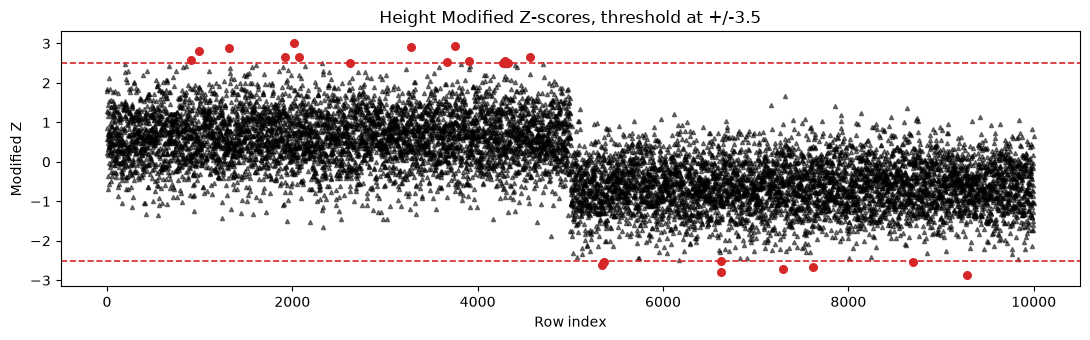

In [69]:
height_median = people["Height"].median()
height_mad = (people["Height"] - height_median).abs().median()
height_mz = 0.6745 * (people["Height"] - height_median) / height_mad

fig, ax = plt.subplots(figsize=(11, 3.5))
plot_scores(height_mz, threshold=2.5, label="Modified Z", ax=ax)
ax.set_xlabel("Row index")
ax.set_title("Height Modified Z-scores, threshold at +/-3.5")
plt.tight_layout()
plt.show()

Zero, where IQR found 8 and the Z-score found 7.

Do not read that as failure. Read it as a **more conservative method disagreeing**, and go and find out why.

The MAD is computed around a median that sits in the valley between the two humps of our mixed population. That makes the typical deviation look large, which widens the threshold, which flags fewer points. The method is behaving exactly as designed. The design assumption, one population, is what does not hold.

The lesson: when methods disagree, the disagreement is information. It is usually telling you something about the data rather than about the code.

## Comparing the three

In [26]:
comparison = pd.DataFrame({
    "IQR (k=1.5)": [iqr_outliers(people["Height"]).sum(), iqr_outliers(people["Weight"]).sum()],
    "Z-score (3.0)": [z_score_outliers(people["Height"]).sum(), z_score_outliers(people["Weight"]).sum()],
    "Modified Z (3.5)": [modified_z_outliers(people["Height"]).sum(), modified_z_outliers(people["Weight"]).sum()],
}, index=["Height", "Weight"])

comparison

,IQR (k=1.5),Z-score (3.0),Modified Z (3.5)
Height,8,7,0
Weight,1,2,0


| Method | Uses | Robust to contamination | Assumes normality | Use when |
| :--- | :--- | :--- | :--- | :--- |
| Tukey IQR | Quartiles | Yes | No | Default choice, any distribution |
| Z-score | Mean, std | **No** | Yes | Known clean, roughly normal data |
| Modified Z | Median, MAD | Yes | No | Skewed or heavy tailed data |

If you take one operational rule from this section: **prefer IQR or Modified Z over the plain Z-score for detection work.** The Z-score is the one that fails precisely when there is something to find.

---
# Part 5: Where univariate methods go blind

Everything so far examined one column at a time. That approach has a limit which no amount of threshold tuning can fix.

Plot height against weight.

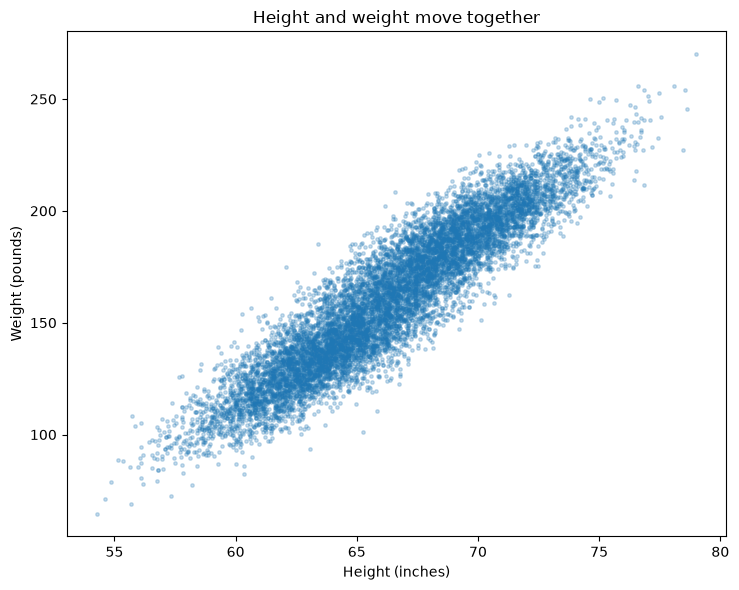

In [27]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(people["Height"], people["Weight"], s=6, alpha=0.25, color="tab:blue")
ax.set_xlabel("Height (inches)")
ax.set_ylabel("Weight (pounds)")
ax.set_title("Height and weight move together")
plt.tight_layout()
plt.show()

The variables are correlated: taller people weigh more. That relationship is the thing univariate methods cannot see.

Consider someone 5 feet 3 inches tall weighing 185 pounds. Check each measurement separately.

In [28]:
test_height, test_weight = 63.4, 185.2

for column, value in [("Height", test_height), ("Weight", test_weight)]:
    q1, q3 = people[column].quantile([0.25, 0.75])
    lower, upper = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    print(f"{column:>6} = {value:>6}   IQR fence {lower:.1f} to {upper:.1f}   flagged? {not lower <= value <= upper}")

Height =   63.4   IQR fence 55.0 to 77.7   flagged? False
Weight =  185.2   IQR fence 58.8 to 264.2   flagged? False


Individually, both values are ordinary. **Jointly, the combination is rare**, because that weight is unusual for that height.

Detecting this requires a method that understands the relationship between columns.

## Mahalanobis distance, built up one piece at a time

Start with the obvious idea and watch it fail. To measure how unusual a point is, measure its distance from the centre of the data. That is ordinary Euclidean distance, and it treats the data cloud as a circle.

Our cloud is not a circle. It is a long diagonal ellipse, because height and weight move together. A point can be close to the centre in plain distance while sitting completely off the diagonal, and a point far along the diagonal is not unusual at all.

**Mahalanobis distance is Euclidean distance after stretching the space so the ellipse becomes a circle.** It asks how far a point is *relative to how the data actually varies in that direction*, which is exactly the question the scatter plot poses.

The formula is:

> `d(x) = sqrt( (x - centre)ᵀ · Σ⁻¹ · (x - centre) )`

Three pieces, and each does one job:

- `(x - centre)` is how far the point sits from the middle, per column. This is the only piece an ordinary distance uses.
- `Σ` (sigma) is the **covariance matrix**: how much each column varies, and how strongly the columns move together.
- `Σ⁻¹`, the inverse, is the part that does the work. It divides out the variance, so a column with a huge spread stops dominating, and it removes the shared movement, so being "tall and heavy together" costs you nothing while being "short and heavy" costs a lot.

Build it from the bottom.

In [29]:
features = people[["Height", "Weight"]].to_numpy()
centre = features.mean(axis=0)
covariance = np.cov(features.T)

print("Centre (mean height, mean weight):", centre.round(2))
print()
print("Covariance matrix:")
print(pd.DataFrame(covariance, index=["Height", "Weight"], columns=["Height", "Weight"]).round(1))

Centre (mean height, mean weight): [ 66.37 161.44]

Covariance matrix:
        Height  Weight
Height    14.8   114.2
Weight   114.2  1031.0


Read that matrix. The diagonal holds each column's variance: about 14.8 for height, about 1031 for weight. Weight varies on a vastly larger numeric scale simply because pounds are bigger numbers than inches.

That alone is a reason plain distance fails. In raw Euclidean terms a 30 pound difference would swamp a 3 inch difference, even though the 3 inches may be the more unusual of the two.

The off-diagonal number, about 114, is the **covariance**: the two columns rise and fall together. That is the diagonal shape in the scatter plot expressed as a number.

Inverting the matrix undoes both effects at once.

Notice what `np.cov` and `features.mean(axis=0)` are built from, though: a mean and a variance. That is the same pair Part 3 showed to be non-robust. Mahalanobis distance solves the *multivariate* blindness of the earlier methods, but it inherits their *contamination* weakness, because the outliers you are hunting help build the ellipse you are measuring against. Scikit-learn's [`MinCovDet`](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.MinCovDet.html) estimates the covariance robustly (the Minimum Covariance Determinant method), and [`EllipticEnvelope`](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.EllipticEnvelope.html) wraps that into a ready-made detector. Swapping one for the other is a one-line change and a good thing to try after this activity. Now compute the distance for the specific person from before, 63.4 inches and 185.2 pounds, and compare the two ways of measuring.

In [30]:
inv_covariance = np.linalg.inv(covariance)

# The short, heavy person from earlier, and a tall heavy person for contrast.
short_heavy = np.array([63.4, 185.2])
tall_heavy = np.array([75.0, 230.0])

for name, point in [("Short and heavy (63.4in, 185.2lb)", short_heavy),
                    ("Tall and heavy  (75.0in, 230.0lb)", tall_heavy)]:
    deviation = point - centre
    euclidean = np.sqrt(deviation @ deviation)
    mahal = np.sqrt(deviation @ inv_covariance @ deviation)
    print(f"{name}")
    print(f"    plain Euclidean distance : {euclidean:6.2f}")
    print(f"    Mahalanobis distance     : {mahal:6.2f}")

Short and heavy (63.4in, 185.2lb)
    plain Euclidean distance :  23.94
    Mahalanobis distance     :   3.90
Tall and heavy  (75.0in, 230.0lb)
    plain Euclidean distance :  69.10
    Mahalanobis distance     :   2.25


**The two measures do not just disagree, they rank the points in opposite orders.**

| Point | Euclidean | Mahalanobis |
| :--- | ---: | ---: |
| Short and heavy | 23.94 | **3.90** |
| Tall and heavy | 69.10 | **2.25** |

By plain distance the tall heavy person is almost **three times further** from the centre and looks far more unusual. By Mahalanobis distance they are the *more normal* of the two.

That inversion is the whole idea. The tall heavy person is a long way out, but they are a long way out **along the diagonal**, in the direction the data naturally travels. Tall people weigh more; nothing about them is surprising. The short heavy person barely moved from the centre in raw units, but they moved **across** the diagonal, into a direction the population does not go.

Euclidean distance measures how far. Mahalanobis measures how surprising. For finding broken records, surprising is what you want.

Now apply it to all 10,000 rows at once.

In [31]:
deviations = features - centre

# Same formula as the single point above, applied to every row.
# (deviations @ inv_covariance) * deviations, summed across columns, is the
# row-by-row version of  deviation @ inv_covariance @ deviation.
mahalanobis = np.sqrt(((deviations @ inv_covariance) * deviations).sum(axis=1))

print("First five distances:", mahalanobis[:5].round(2))
print("Largest distance    :", mahalanobis.max().round(2))

First five distances: [2.69 1.58 2.13 1.98 1.72]
Largest distance    : 4.26


## Choosing the cutoff, and why chi-squared appears

Now you need a threshold, and this is the one place Mahalanobis gives you something the earlier methods could not: a **principled** cutoff rather than a convention like 1.5 or 3.5.

Here is the useful fact. If your data really is multivariate normal, then the **squared** Mahalanobis distances follow a chi-squared distribution, with degrees of freedom equal to the number of columns you used.

That converts threshold choice into a probability question. Instead of picking a distance out of the air, you say "flag the most extreme 0.1 percent" and let the distribution tell you which distance that is.

- `df=2` because we used exactly two columns, `Height` and `Weight`. Use five columns and it becomes `df=5`.
- `0.999` is the quantile, meaning 99.9 percent of well behaved points should fall below it. Change this number to change how aggressive the detector is, exactly like `k` and the Z threshold before it.
- `np.sqrt` because chi-squared describes the *squared* distances, and we computed unsquared ones.

The result that squared Mahalanobis distances are chi-squared is standard multivariate statistics; the [scipy chi-squared reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html) documents `ppf`, the inverse cumulative distribution function, which is what turns "the most extreme 0.1 percent" into a number.

One honest caveat, since we spent Part 1 establishing it: our data is a mixture of two populations, so it is **not** multivariate normal. The chi-squared threshold is therefore an approximation here, not a guarantee. It remains a far better starting point than a number you invented, and it is still a dial you own.

In [32]:
threshold = np.sqrt(stats.chi2.ppf(0.999, df=2))
maha_outliers = mahalanobis > threshold

print(f"Chi-squared threshold at 99.9 percent, df=2: {threshold:.3f}")
print("Mahalanobis outliers:", maha_outliers.sum())

Chi-squared threshold at 99.9 percent, df=2: 3.717
Mahalanobis outliers: 5


Now compare directly against what the univariate methods found.

In [33]:
univariate_outliers = (iqr_outliers(people["Height"]) | iqr_outliers(people["Weight"])).to_numpy()

print("Found by univariate IQR         :", univariate_outliers.sum())
print("Found by Mahalanobis            :", maha_outliers.sum())
print("Found ONLY by Mahalanobis       :", (maha_outliers & ~univariate_outliers).sum())

Found by univariate IQR         : 8
Found by Mahalanobis            : 5
Found ONLY by Mahalanobis       : 4


In [34]:
missed = people[maha_outliers & ~univariate_outliers]
missed[["Gender", "Height", "Weight"]].round(1)

,Gender,Height,Weight
727,Male,63.4,185.2
1243,Male,62.1,175.1
7821,Female,65.3,101.0
9774,Female,65.8,110.5


These rows are invisible to every univariate method in this notebook, at any threshold.

Read them and the pattern is clear. Two are heavier than their height predicts, two are lighter than their height predicts. Every individual number sits comfortably inside its column's normal range. Every **pairing** sits off the diagonal that the rest of the population follows.

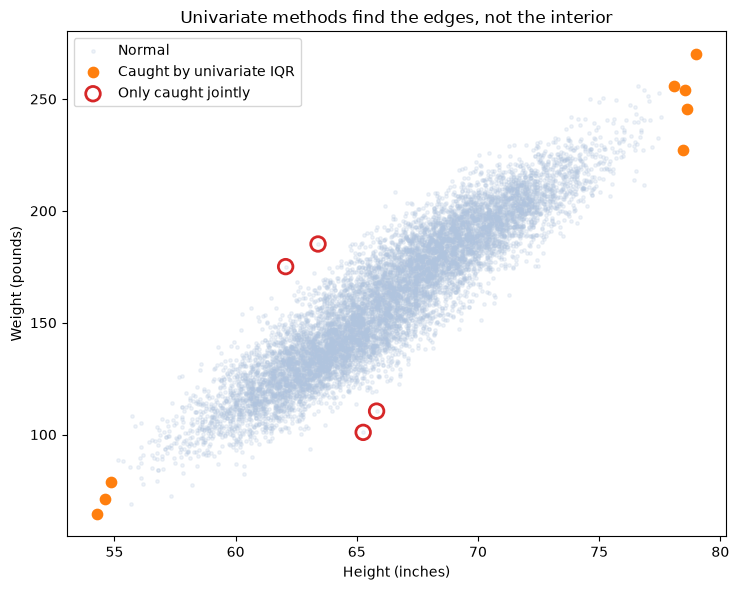

In [35]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(people["Height"], people["Weight"], s=6, alpha=0.2, color="lightsteelblue", label="Normal")
ax.scatter(people.loc[univariate_outliers, "Height"], people.loc[univariate_outliers, "Weight"],
           s=55, color="tab:orange", label="Caught by univariate IQR", zorder=3)
ax.scatter(missed["Height"], missed["Weight"],
           s=110, facecolors="none", edgecolors="tab:red", linewidths=2,
           label="Only caught jointly", zorder=4)
ax.set_xlabel("Height (inches)")
ax.set_ylabel("Weight (pounds)")
ax.set_title("Univariate methods find the edges, not the interior")
ax.legend()
plt.tight_layout()
plt.show()

This chart is the argument for multivariate detection in one image.

The orange points are at the **outer edges** of the cloud, which is exactly what a per column range check finds. The red circled points sit **inside** the overall range but **off the diagonal**, away from the relationship the population follows.

Real data quality problems very often look like the red points. A transposed pair of fields, a unit conversion applied to one column but not another, or a record stitched together from two different sources all produce values that are individually plausible and jointly impossible.

### Try it yourself

The chi-squared quantile is a dial, and you have not touched it yet.

1. Recompute `maha_outliers` using `0.99` instead of `0.999`.
2. Print how many rows are flagged, and how many of those the univariate IQR method also found.
3. Try `0.9999` as well.

**What to look for:** at `0.99` you should get substantially more than 5 flagged rows. Ask yourself whether the extra rows look like broken records or just ordinary people at the edge of the cloud.

**The engineering point:** moving from 0.999 to 0.99 is the same kind of decision as moving `k` from 1.5 to 1.0. The chi-squared framing makes the cutoff *principled*, but it does not make it *automatic*. You still own the number, and you still have to defend it.

In [36]:
# Your turn: try quantiles of 0.99 and 0.9999 and compare the flag counts.
# Hint: only the first argument to stats.chi2.ppf changes.



---
# Part 6: Time series, where the definition of normal moves

There is one more assumption to break. Every method so far assumed rows are **interchangeable**, that shuffling the dataset changes nothing.

For a time series, that is false. Order carries meaning.

Load the NYC taxi dataset, a standard anomaly detection benchmark, recording passenger counts every 30 minutes. It comes from the [Numenta Anomaly Benchmark](https://github.com/numenta/NAB), a public corpus of real time series with hand-labelled anomalies, built specifically so that detectors can be scored rather than admired. Benchmarks like this are rare, and the reason this activity can make honest claims about what was missed.

In [37]:
taxi = pd.read_csv(DATA_DIR / "nyc_taxi.csv", parse_dates=["timestamp"])
print(taxi.shape)
print("From", taxi["timestamp"].min(), "to", taxi["timestamp"].max())
taxi.head()

(10320, 2)
From 2014-07-01 00:00:00 to 2015-01-31 23:30:00


,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


In [38]:
daily = taxi.set_index("timestamp").resample("D")["value"].sum()
print("Daily observations:", len(daily))

Daily observations: 215


This benchmark ships with **labelled events**, which is rare and valuable. We know what actually happened on these dates, so we can measure detection honestly rather than admiring plausible looking flags.

In [39]:
KNOWN_EVENTS = {
    "2014-11-02": "NYC Marathon",
    "2014-11-27": "Thanksgiving",
    "2014-12-25": "Christmas",
    "2015-01-01": "New Year's Day",
    "2015-01-27": "North American Blizzard",
}

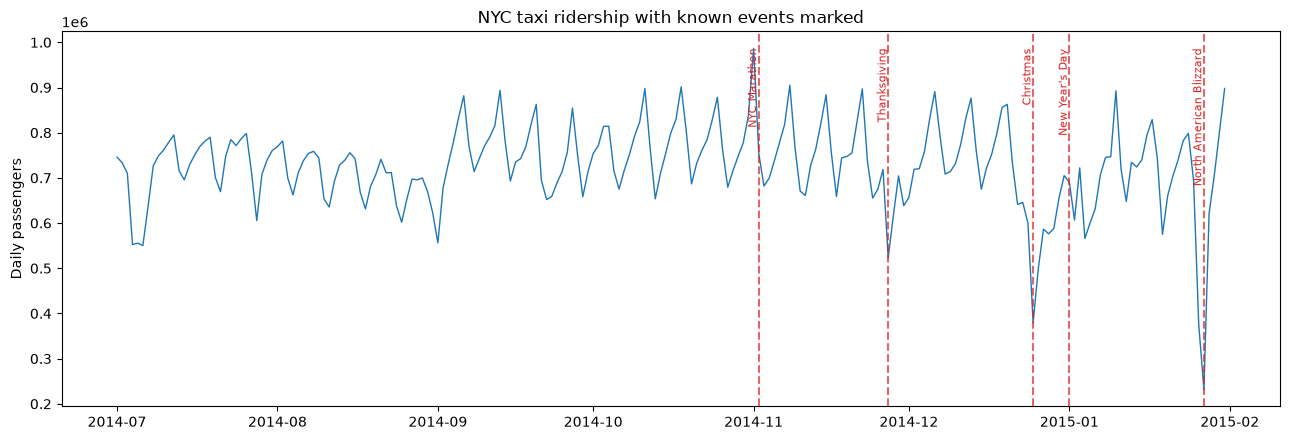

In [40]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index, daily.values, color="tab:blue", lw=1)
for date, label in KNOWN_EVENTS.items():
    ts = pd.Timestamp(date)
    if ts in daily.index:
        ax.axvline(ts, color="tab:red", ls="--", alpha=0.7)
        ax.annotate(label, (ts, daily.max()), rotation=90,
                    fontsize=8, va="top", ha="right", color="tab:red")
ax.set_ylabel("Daily passengers")
ax.set_title("NYC taxi ridership with known events marked")
plt.tight_layout()
plt.show()

Some events are visibly dramatic. Others are not. Now apply the statistical methods and score them against the labels.

In [41]:
daily_iqr = iqr_outliers(daily)
daily_z = z_score_outliers(daily)
daily_mz = modified_z_outliers(daily)

print("Flagged by IQR        :", daily_iqr.sum())
print("Flagged by Z-score    :", daily_z.sum())
print("Flagged by Modified Z :", daily_mz.sum())

Flagged by IQR        : 6
Flagged by Z-score    : 3
Flagged by Modified Z : 4


### Predict before you run

The next cell scores each of the five labelled events against all three methods. Commit to an answer first, because the result is the point of the whole activity and it lands harder if you have guessed.

Five real events. A blizzard that shut the city, Thanksgiving, Christmas, New Year's Day, and the NYC Marathon.

**How many of the five do you expect the methods to catch?**

Write your guess down. Most people say four or five, on the reasoning that these are the most disrupted days of the year and the whole point of an outlier detector is to find disrupted days.

Now run it.

In [42]:
z_values = (daily - daily.mean()) / daily.std()

rows = []
for date, label in KNOWN_EVENTS.items():
    ts = pd.Timestamp(date)
    rows.append({
        "event": label,
        "passengers": int(daily[ts]),
        "z_score": round(z_values[ts], 2),
        "IQR": bool(daily_iqr[ts]),
        "Z-score": bool(daily_z[ts]),
        "Modified Z": bool(daily_mz[ts]),
    })

pd.DataFrame(rows)

,event,passengers,z_score,IQR,Z-score,Modified Z
0,NYC Marathon,753705,0.29,False,False,False
1,Thanksgiving,523184,-2.19,True,False,False
2,Christmas,379302,-3.73,True,True,True
3,New Year's Day,690407,-0.39,False,False,False
4,North American Blizzard,232058,-5.32,True,True,True


---
# Part 7: Read that table carefully

This is the most important result in the activity.

**The blizzard and Christmas were caught by everything.** Ridership collapsed, they are far from the mean in absolute terms, and any method finds them. These are **point anomalies**: extreme values judged against the whole series.

**Thanksgiving was caught only by IQR.** Both Z-score variants missed it. Its Modified Z-score lands around 3.1, just under the conventional 3.5 cutoff, so a threshold chosen by convention rather than by evidence is the entire reason a real holiday went undetected.

**The NYC Marathon and New Year's Day were missed by every single method.**

Look at the Marathon's Z-score: about +0.29. In total daily ridership it is one of the most ordinary days in the entire dataset.

Yet on Marathon day, streets across Manhattan close, the subway reroutes, and taxi movement changes completely. Something enormous happened. The daily total does not show it, because the changes cancel out when you sum over 24 hours.

New Year's Day is the same story. Extremely quiet morning, extremely busy the night before, and the total lands close to average.

## Three kinds of anomaly

This gives us the vocabulary that the rest of the day depends on. The three-way split is the standard one from [Chandola, Banerjee and Kumar's *Anomaly Detection: A Survey* (2009)](https://doi.org/10.1145/1541880.1541882), still the most cited map of this field and worth skimming for the sheer breadth of methods it catalogues.

**Point anomaly.** A value extreme against the whole series. The blizzard. Statistical methods find these well, and they are the only kind these methods find reliably.

**Contextual anomaly.** A value that is normal globally but wrong **for its context**. 700,000 passengers is a fine number, unless it is a Sunday in November when the city is closed for a marathon. Detection requires the model to know the context: hour of day, day of week, whether it is a holiday.

**Collective anomaly.** No individual value is unusual, but the **sequence** is. A flat line for six hours where each individual reading is plausible. A pattern that repeats at the wrong frequency. Detection requires looking at windows rather than points.

The taxi results map cleanly onto this. The methods in this notebook caught the point anomalies and were structurally incapable of catching the contextual ones. That is not a tuning problem. No threshold on a daily total will ever surface the Marathon, because the daily total genuinely is normal.

## First attempt at recovering context

The obvious fix is to change the reference population. Instead of comparing each day to the whole series, compare it to **the same weekday**.

In [43]:
frame = daily.to_frame("passengers")
frame["weekday"] = frame.index.dayofweek
frame["weekday_median"] = frame.groupby("weekday")["passengers"].transform("median")
frame["pct_of_typical"] = frame["passengers"] / frame["weekday_median"]

In [44]:
for date, label in [("2014-11-02", "NYC Marathon"), ("2015-01-01", "New Year's Day")]:
    ts = pd.Timestamp(date)
    row = frame.loc[ts]
    print(f"{label:16s} {row['passengers']:>8.0f} passengers, "
          f"{row['pct_of_typical']:.1%} of a typical {ts.day_name()}")

NYC Marathon       753705 passengers, 105.1% of a typical Sunday
New Year's Day     690407 passengers, 90.8% of a typical Thursday


**That barely helped.**

The Marathon comes out at about 105 percent of a typical Sunday and New Year's Day at about 91 percent of a typical Thursday. Both are still completely unremarkable. A better reference population did not rescue the detection.

Resist the urge to try a cleverer statistic here. The problem is not the statistic.

## The real culprit is the aggregation

Go back to what we did at the very start of Part 6: we took data recorded **every 30 minutes** and summed it into daily totals.

On Marathon day, ridership is heavily suppressed in some hours and elevated in others. Summing over 24 hours makes those swings **cancel each other out**. The information was not hidden by a weak method. It was destroyed by the aggregation, before any method ran.

No detector can recover a signal that the pipeline already threw away.

Test that claim. Keep the 30 minute granularity, and compare each slot to the median for that same weekday and time of day.

In [45]:
slots = taxi.set_index("timestamp").copy()
slots["weekday"] = slots.index.dayofweek
slots["time_of_day"] = slots.index.hour * 60 + slots.index.minute

slots["expected"] = slots.groupby(["weekday", "time_of_day"])["value"].transform("median")
slots["residual"] = slots["value"] - slots["expected"]

Now apply the Modified Z-score to the **residuals**, meaning how far each slot sits from what that particular slot normally looks like.

In [46]:
residual_median = slots["residual"].median()
residual_mad = (slots["residual"] - residual_median).abs().median()
slots["modified_z"] = 0.6745 * (slots["residual"] - residual_median) / residual_mad

slots["is_extreme"] = slots["modified_z"].abs() > 3.5

In [47]:
per_day = slots.groupby(slots.index.date)["is_extreme"].sum()

print("Extreme 30-minute slots on a typical day (median):", int(per_day.median()))
print()
for date, label in KNOWN_EVENTS.items():
    day = slots.loc[date]
    print(f"{label:26s} extreme slots: {int(day['is_extreme'].sum()):>3}   "
          f"largest |modified Z|: {day['modified_z'].abs().max():.1f}")

Extreme 30-minute slots on a typical day (median): 0

NYC Marathon               extreme slots:  10   largest |modified Z|: 14.6
Thanksgiving               extreme slots:  29   largest |modified Z|: 11.9
Christmas                  extreme slots:  34   largest |modified Z|: 15.7
New Year's Day             extreme slots:  34   largest |modified Z|: 19.9
North American Blizzard    extreme slots:  41   largest |modified Z|: 17.1


Every one of the five events is now clearly detected, including the two that were completely invisible before.

A typical day has **zero** extreme slots. The Marathon has around ten, with a peak Modified Z-score near 15. New Year's Day is even more pronounced. The same simple statistic that failed at daily granularity succeeds easily at 30 minute granularity.

Confirm the detector is finding real events rather than just producing more flags.

In [48]:
per_day.sort_values(ascending=False).head(10)

2015-01-27    41
2014-07-05    38
2014-12-27    34
2014-12-25    34
2015-01-01    34
2014-12-26    32
2014-11-27    29
2014-08-30    28
2014-07-04    26
2014-09-01    23
Name: is_extreme, dtype: int64

Read that list. Blizzard, Independence Day and the day after, the entire Christmas and New Year stretch, Thanksgiving, Labor Day weekend. Almost every top ranked day is a genuine holiday or major event.

## The lesson worth carrying

The most important decision in this notebook was not IQR versus Z-score versus Modified Z. It was **the choice to aggregate to daily totals**, and it was made before any detection code existed.

For a data engineer this is the recurring shape of the problem. Aggregation, sampling rate, partitioning, and retention are all decided early, usually for storage and query cost reasons, and each one silently determines which questions can ever be answered downstream. A detector cannot outperform the granularity it is fed.

When someone reports that anomaly detection is not working, check what the data went through before it arrived. The failure is often upstream of the algorithm.

One more thing worth naming. The `groupby(["weekday", "time_of_day"])` you just wrote is a hand-rolled **seasonal decomposition**: you split each reading into an expected seasonal component and a residual, then hunted anomalies in the residual. That is a well developed field with better tools. [`statsmodels` STL](https://www.statsmodels.org/stable/examples/notebooks/generated/stl_decomposition.html) does the same split with a trend term and a seasonality that is allowed to change over time, and [`seasonal_decompose`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html) is the simpler classical version. The reason to write it by hand first is that when STL surprises you, you will know what it was trying to do.

---
# Your Turn

Work in your own copy under `student-work/week6/day2/`.

Each challenge lists what you should see if it is working, so you can check yourself without an answer key. Challenges 1 and 2 are the core; 3 and 4 are the stretch.

## Challenge 1: Detect within groups

Every threshold in Part 2 through Part 4 was computed across a mixed male and female population, which we established is two distributions in a trench coat.

1. Compute IQR outliers for `Height` **separately within each gender**, then combine the results.
2. Compare the total against the 8 found on the pooled data.
3. Identify any row flagged within its group but not in the pooled analysis, and explain in a markdown cell why pooling hid it.

**Hint:** `people.groupby("Gender")["Height"].transform(...)` lets you compute per-group quartiles without splitting the frame.

**What you should see:** the per-group total is *dramatically* larger than 8, in the region of seventy rows rather than single digits, and all of the original 8 are still flagged. Grouping tightens both thresholds, because each gender's spread is far narrower than the spread of the two combined.

**Success criteria**
- [ ] Per-group flag count computed and compared against the pooled 8.
- [ ] At least one row identified that grouping caught and pooling missed.
- [ ] Written explanation connects the result back to the two-hump histogram in Part 1.

## Challenge 2: Build a threshold sensitivity table

For `Weight`, produce a table with one row per method (IQR, Z-score, Modified Z) and one column per threshold setting, showing the count flagged in each combination. Use at least four threshold values per method.

Then answer: which method's output is most sensitive to its threshold, and what does that imply about deploying it where you cannot easily retune?

**What you should see:** counts that fall away sharply as thresholds loosen, reaching zero for every method well before the loosest setting. Recall from Part 2 that `Height` already flagged nothing at `k=2.0`.

**Success criteria**
- [ ] A single table with methods as rows and thresholds as columns.
- [ ] An explicit claim about which method is most threshold-sensitive, supported by the numbers in your table.
- [ ] A sentence on what that means for a pipeline you cannot easily retune.

## Challenge 3: Hunt the collective anomaly

Point anomalies were covered. Now find a collective one.

1. Resample the taxi data to hourly instead of daily.
2. Compute a 24 hour rolling standard deviation.
3. Find the windows where that rolling standard deviation is unusually **low**, meaning the series went abnormally flat.
4. Plot one of those windows against a normal day.

A flat line in a series that normally has a strong daily rhythm is frequently a **broken sensor or a stalled pipeline**, not a real measurement.

**Hint:** `series.rolling(24).std()` gives you the rolling figure. You are looking for the *smallest* values, so `nsmallest` rather than `nlargest`.

**What you should see:** the flattest windows all land on **27 January 2015**, the blizzard. The city shut down, so the usual daily rhythm of rush hours and overnight lulls flattened into a low, steady line for a full day.

That result is worth thinking about carefully. You went looking for a broken feed and found a real event, using a method that never looked at whether any individual value was extreme. The shape of the day was the anomaly.

**Success criteria**
- [ ] Rolling standard deviation computed on hourly data.
- [ ] At least one low-variance window plotted against a normal day.
- [ ] Written explanation of why a plain IQR check on the raw values would never find this.
- [ ] A written answer to this: your detector found a genuine event rather than a fault. What extra signal would you need to tell a flat line caused by a blizzard from a flat line caused by a dead feed?

## Challenge 4: Justify a threshold to a stakeholder

You are adding an automated quality gate to the taxi ingestion pipeline. Flagged days are held for manual review before loading.

Reviewing one day costs approximately 20 minutes of an analyst's time. Loading a genuinely corrupt day means a public dashboard shows wrong numbers until someone notices.

In a markdown cell of no more than 200 words: choose a method and a threshold, estimate the weekly review burden using the counts you measured, and state which of the two errors you chose to favour and why.

**Success criteria**
- [ ] A specific method and threshold named, not a range.
- [ ] A weekly review burden in hours, derived from counts you actually computed.
- [ ] An explicit statement of which error you chose to favour, with the reason.

There is no correct answer. There is a defensible answer, and that is what you are being asked for.

---
## What you did

- Established that "outlier" is a claim about a reference population, not a property of a row.
- Implemented IQR, Z-score, and Modified Z-score from scratch.
- Found the Z-score's hard ceiling of `(n-1)/sqrt(n)`, and saw a value of 500 pinned exactly against it.
- Demonstrated **masking**: as contamination grew from one bad value to four, the Z-score got quieter rather than louder.
- Found IQR's **breakdown point**, where 29 percent contamination silenced it too, and saw the Modified Z-score survive all four cases.
- Built Mahalanobis distance from the covariance matrix up, and showed it ranks a "short and heavy" point as more anomalous than one three times further away in plain distance.
- Showed that univariate methods cannot see anomalies that exist only in the relationship between columns.
- Named the three anomaly types: point, contextual, and collective.
- Measured, against labelled real events, that on daily totals every method **missed the NYC Marathon and New Year's Day entirely**.
- Traced that failure to the aggregation rather than to the algorithm, and recovered all five events by detecting at 30 minute granularity against a per weekday, per time of day reference.

## Two reflexes worth keeping

**A quiet detector is not the same as clean data.** You saw this three separate times: IQR silent at `k=2.0` because the boundary outran the data, the Z-score silent under heavy contamination, and every method silent on the Marathon. In all three the output looked identical to "nothing is wrong".

**When methods disagree, the disagreement is information.** The Modified Z-score found zero outliers in the height data where IQR found 8. That was not a bug in either method. It was both methods correctly reporting on a population that is secretly two populations.

## The open problem

Notice what the taxi fix actually required. You had to know, in advance, that the right context was weekday **and** time of day, and you had to build that reference by hand with a `groupby`.

That works because this dataset has one column and one obvious seasonal structure. It does not scale. Given a claims table with forty columns, you cannot hand craft the correct reference population for every combination that might matter, and you will not guess in advance which interactions carry the anomalies.

What you want is a method that **learns the structure itself**, across many columns at once, without being told where to look.

Next: **Activity 3**, where Isolation Forest does exactly that, and where you find out what it costs you in explainability to get it.

---
## Go deeper

### The methods

| Resource | Why it is worth your time |
| :--- | :--- |
| [NIST/SEMATECH Engineering Statistics Handbook](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm) | Free, authoritative, and written for engineers rather than statisticians. The outlier detection section covers everything in Parts 2 to 4 with the formal tests alongside. |
| [Chandola, Banerjee and Kumar, *Anomaly Detection: A Survey*](https://doi.org/10.1145/1541880.1541882) | The map of the whole field, and the source of the point / contextual / collective vocabulary you now own. |
| [scikit-learn: novelty and outlier detection](https://scikit-learn.org/stable/modules/outlier_detection.html) | The practical menu, with a [side-by-side comparison on toy datasets](https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_anomaly_comparison.html) that shows very clearly which method finds which shape. Read this before Activity 3. |
| [Shiffler (1988), *Maximum Z Scores and Outliers*](https://doi.org/10.1080/00031305.1988.10475530) | Two pages, and the source of the `(n-1)/sqrt(n)` ceiling you measured in Part 3. |
| [Rousseeuw and Hubert, *Robust statistics for outlier detection*](https://doi.org/10.1002/widm.2) | Where breakdown points, MAD, and the Minimum Covariance Determinant come from, by the people who developed them. |

### The tools

| Tool | What it adds beyond this notebook |
| :--- | :--- |
| [`scipy.stats.median_abs_deviation`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.median_abs_deviation.html) | The MAD you wrote by hand, with `scale="normal"` applying the 0.6745 rescaling for you. |
| [`sklearn.covariance.EllipticEnvelope`](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.EllipticEnvelope.html) | Mahalanobis distance with a **robust** covariance estimate, closing the weakness flagged in Part 5. |
| [`statsmodels` STL decomposition](https://www.statsmodels.org/stable/examples/notebooks/generated/stl_decomposition.html) | The principled version of the per weekday, per time of day baseline you built by hand in Part 7. |
| [Numenta Anomaly Benchmark](https://github.com/numenta/NAB) | 58 labelled real time series, including the taxi data. The honest way to compare detectors is to score them here rather than to eyeball their flags. |
| [PyOD](https://pyod.readthedocs.io/) | Roughly 50 outlier detection algorithms behind one scikit-learn style API, with benchmark results. The fastest way to find out whether a fancier method actually beats your IQR rule. |
| [Great Expectations](https://greatexpectations.io/) and [Soda Core](https://www.soda.io/) | Where a threshold you have defended actually lives in a production pipeline, as a test that fails the run. |

### Two questions to carry forward

**What is your reference population, really?** Every number in this notebook changed when the reference changed: pooled versus per gender, whole series versus same weekday, daily total versus 30 minute slot. Before you write a detector, write down the comparison group. It is a more consequential decision than the algorithm.

**Who reviews the flags?** A detector with no review process attached is not a quality control, it is a source of alerts nobody reads. Challenge 4 asks you to price the review burden for a reason.